In [ ]:
import os, gc, torch, sys, glob, shutil
from pathlib import Path
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU total memory (GB):", round(torch.cuda.get_device_properties(0).total_memory/1e9, 2))


Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
PyTorch: 2.8.0+cu126
CUDA available: True
GPU: Tesla T4
GPU total memory (GB): 15.83


In [ ]:
!pip -q install --upgrade ultralytics>=8.2.0 tqdm

In [ ]:
!pip install Pillow==9.5.0 --quiet

In [ ]:
from ultralytics import YOLO
from IPython.display import display, Image

In [ ]:
model = YOLO("yolov8n.pt")     # nano is best for Colab T4
use_half = torch.cuda.is_available()


WARNING ⚠️ Download failure, retrying 1/3 https://ultralytics.com/images/bus.jpg... HTTP Error 403: Forbidden
image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 129.5ms
Speed: 13.2ms preprocess, 129.5ms inference, 4.6ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/pretrain_pred


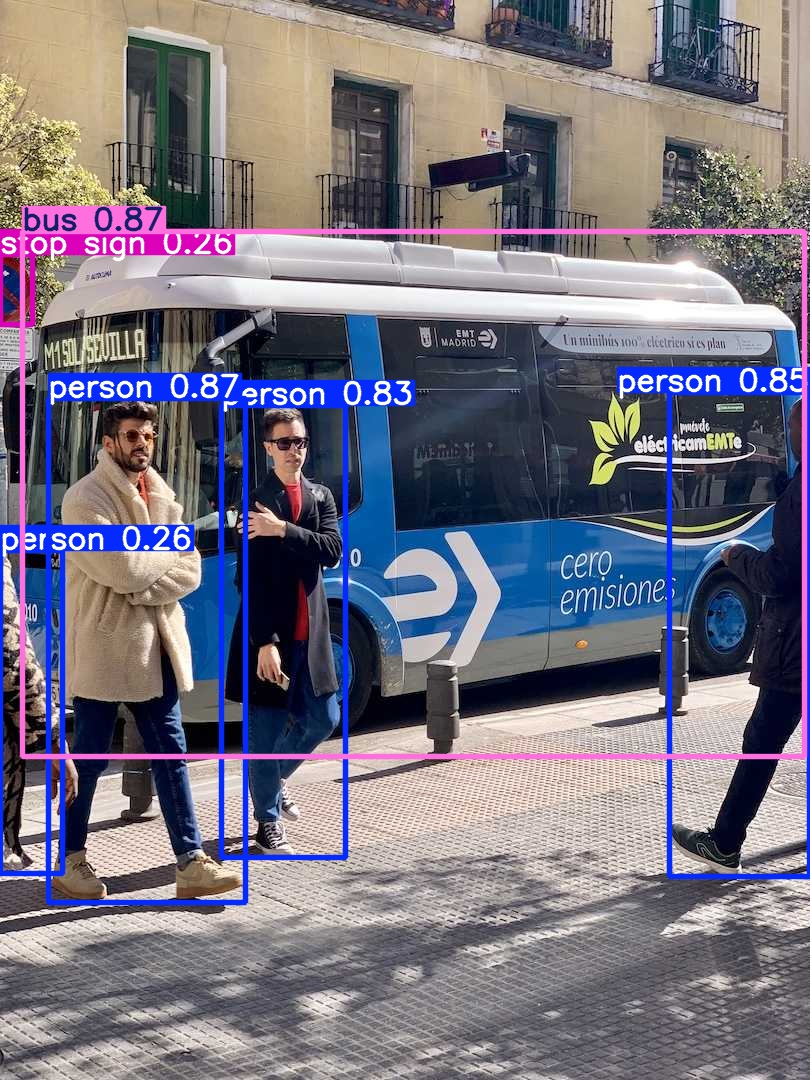

In [ ]:
test_img = "https://ultralytics.com/images/bus.jpg"
_ = model.predict(
    source=test_img, imgsz=640, conf=0.25, max_det=100,
    device=0 if torch.cuda.is_available() else "cpu",
    half=use_half, save=True, project="runs", name="pretrain_pred", exist_ok=True
)
for f in sorted(glob.glob("runs/pretrain_pred/*")):
    if f.lower().endswith((".jpg",".jpeg",".png")):
        display(Image(filename=f))

In [ ]:
train_params = dict(
    data="coco8.yaml",       # replace with your YAML for custom data
    epochs=20,               # start small; increase if stable
    imgsz=448,               # drop to 416/448 if OOM
    batch=8,                # drop to 8 if OOM
    device=0 if torch.cuda.is_available() else "cpu",
    workers=2,
    amp=True,                # mixed precision
    freeze=10,               # freeze first N layers (light FT)
    lr0=0.01,                # safe default
    weight_decay=0.0005,
    patience=5,              # early stop if no val improvement
    optimizer="SGD",         # simple & stable
    cos_lr=True,             # smooth schedule
    mosaic=0.0,              # reduce heavy aug on tiny data
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,  # moderate color aug
    seed=42,
    save=True,
    project="runs",
    name="yolov8n_finetune",
    exist_ok=True
)

results = model.train(**train_params)

Ultralytics 8.3.226 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=448, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.0, multi_scale=False, name=yolov8n_finetune, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patience=5, perspective=0.0, plots=True, pose=12.0, pretrained=Tr

In [ ]:
val_metrics = model.val(
    data="coco8.yaml",
    imgsz=512,
    batch=16,
    device=0 if torch.cuda.is_available() else "cpu",
    workers=2
)
print(val_metrics)

Ultralytics 8.3.226 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1352.6±185.2 MB/s, size: 54.0 KB)
val: Scanning /content/datasets/coco8/labels/val.cache... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 6.8Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 6.2it/s 0.2s
                   all          4         17   0.000151     0.0167   0.000596   5.96e-05
                person          3         10   0.000906        0.1    0.00358   0.000358
                   dog          1          1          0          0          0          0
                 horse          1          2          0          0          0          0
              elephant          1          2          0          0          0          0
              umbrella          1          1         

In [ ]:
import os

weights_path = "runs/yolov8n_finetune/weights/best.pt"
if os.path.exists(weights_path):
    print(f"The best weights were found at: {weights_path}")
else:
    print(f"The best weights were not found at: {weights_path}")
    # Check the /content/runs/detect/yolov8n_finetune/weights directory as well
    detect_weights_path = "runs/detect/yolov8n_finetune/weights/best.pt"
    if os.path.exists(detect_weights_path):
        print(f"The best weights were found at: {detect_weights_path}")
    else:
        print("Could not find the best weights in the expected directories.")

The best weights were found at: runs/yolov8n_finetune/weights/best.pt



Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 (no detections), 9.3ms
Speed: 2.5ms preprocess, 9.3ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/posttrain_pred


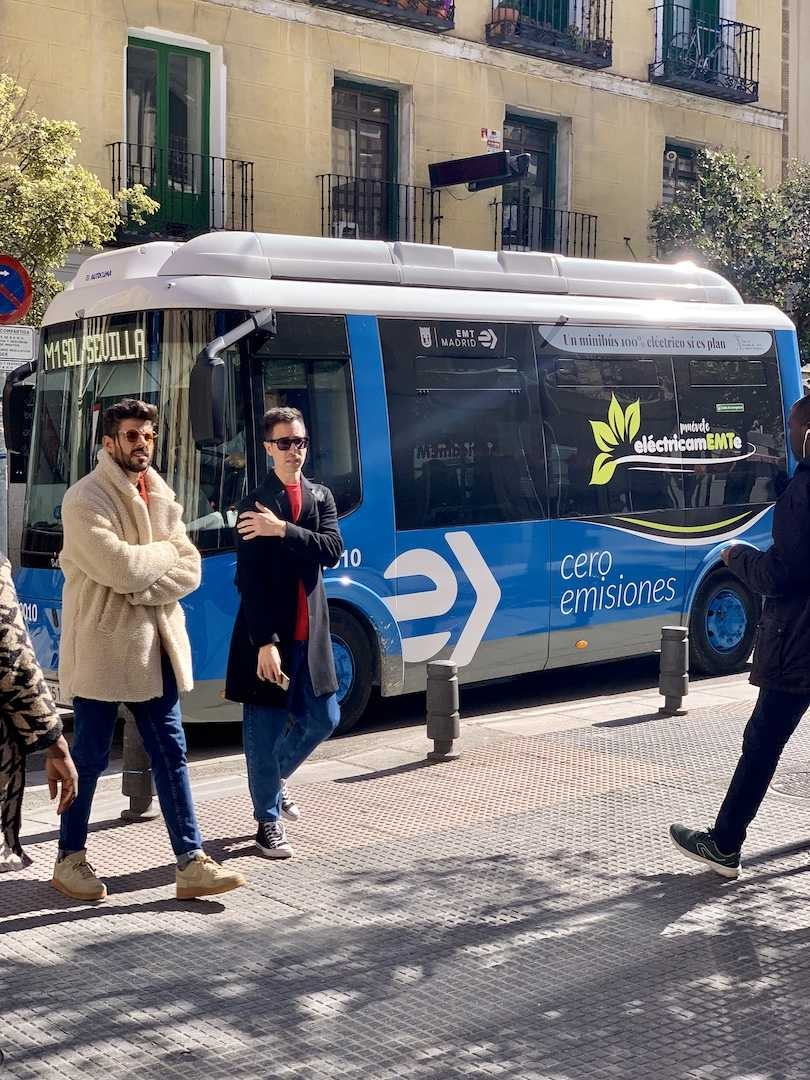

In [ ]:
best_weights = Path("runs/yolov8n_finetune/weights/best.pt")
assert best_weights.exists(), "Best weights not found. Check the training logs."

ft_model = YOLO(str(best_weights))
# Run on sample image
_ = ft_model.predict(
    source=test_img, imgsz=640, conf=0.25, max_det=100,
    device=0 if torch.cuda.is_available() else "cpu",
    half=use_half, save=True, project="runs", name="posttrain_pred", exist_ok=True
)
for f in sorted(glob.glob("runs/posttrain_pred/*")):
    if f.lower().endswith((".jpg",".jpeg",".png")):
        display(Image(filename=f))